Gradient Descent For Logistic Regression

In [1]:
#Importing Modules And Libraries 
import copy,math,numpy as np,matplotlib.pyplot as plt
%matplotlib widget
from lab_utils_common_class import dlc,plot_data,plt_tumor_data,sigmoid,compute_cost_logistic
from plt_quad_logistic import plt_quad_logistic,plt_prob
plt.style.use('./deeplearning.mplstyle')


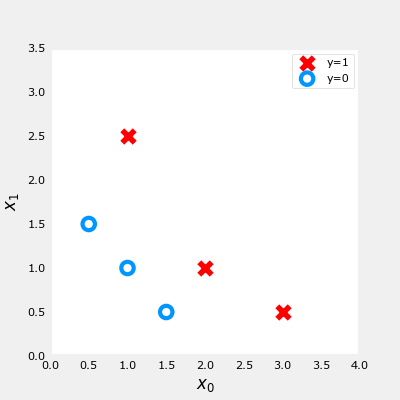

In [2]:
#Loading Data Set 
x_train=np.array([[0.5,1.5],[1,1],[1.5,0.5],[3,0.5],[2,1],[1,2.5]])
y_train=np.array([0,0,0,1,1,1])

#Plotting Data Set
fig,ax=plt.subplots(1,1,figsize=(4,4))
plot_data(x_train,y_train,ax)
ax.axis([0,4,0,3.5])
ax.set_ylabel('$x_1$',fontsize=12)
ax.set_xlabel('$x_0$',fontsize=12)
plt.show()

In [3]:
#Implementing Gradient Function
def logistic_grad(x,y,w,b):
    m,n=x.shape
    dj_dw=np.zeros((n,))
    dj_db=0.
    for i in range(m):
        f=sigmoid(np.dot(x[i],w)+b)
        err=f-y[i]
        for j in range(n):
            dj_dw[j]+=err*x[i,j]
        dj_db+=err
    dj_dw/=m
    dj_db/=m
    return dj_db,dj_dw

In [4]:
#Checking The Implementation Of The Gradient Function
temp_x=np.array([[0.5,1.5],[1,1],[1.5,0.5],[3,0.5],[2,2],[1,2.5]])
temp_y=np.array([0,0,0,1,1,1])
temp_w=np.array([2.,3.])
temp_b=1.
temp_dj_db,temp_dj_dw=logistic_grad(temp_x,temp_y,temp_w,temp_b)
print(f"dj_db:{temp_dj_db}")
print(f"dj_dw:{temp_dj_dw.tolist()}")

dj_db:0.49861806546328574
dj_dw:[0.498333393278696, 0.49883942983996693]


In [5]:
#Implementing Gradient Descent 
def grad_descent(x,y,w_in,b_in,alpha,iter):
    #Array For Storing J And w At Each Iteration For Graphing
    j_arr=[]
    w=copy.deepcopy(w_in) #Avoiding Global w Within Function
    b=b_in
    for i in range(iter):
        dj_db,dj_dw=logistic_grad(x,y,w,b)
        w-=alpha*dj_dw
        b-=alpha*dj_db
        if i<100000:
            j_arr.append(compute_cost_logistic(x,y,w,b))
        if i%math.ceil(iter/10)==0:
            print(f"Iteration {i:4d}->Cost:{j_arr[-1]}")
    return w,b,j_arr 


In [6]:
temp_w=np.zeros_like(x_train[0])
temp_b=0.
alpha=0.1
iter=10000
w_out,b_out,_=grad_descent(x_train,y_train,temp_w,temp_b,alpha,iter)
print(f"\nUpdated Parameters--> w:{w_out},b:{b_out}")

Iteration    0->Cost:0.6865202477843675
Iteration 1000->Cost:0.21281856933380494
Iteration 2000->Cost:0.12129570147968916
Iteration 3000->Cost:0.08462159675184149
Iteration 4000->Cost:0.0650338917532769
Iteration 5000->Cost:0.052863120035998246
Iteration 6000->Cost:0.044566293378348415
Iteration 7000->Cost:0.03854544337812785
Iteration 8000->Cost:0.03397515560140915
Iteration 9000->Cost:0.03038624886148822

Updated Parameters--> w:[6.42 5.23],b:-15.190059272916207


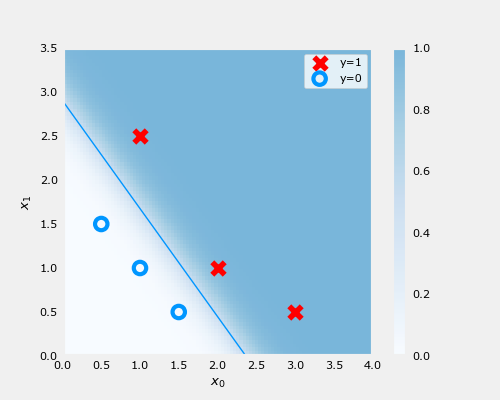

In [7]:
#Plotting The Results Of Gradient Descent
fig,ax=plt.subplots(1,1,figsize=(5,4))
#Probability Plot
plt_prob(ax,w_out,b_out)
#Original Data
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')   
ax.axis([0,4,0,3.5])
plot_data(x_train,y_train,ax)
#Decision Boundary
x0=-b_out/w_out[0]
x1=-b_out/w_out[1]
ax.plot([0,x0],[x1,0],c=dlc["dlblue"],lw=1)
plt.show()

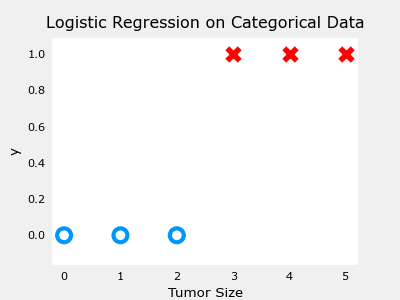

In [8]:
#Another Data Set 
x_train=np.array([0.,1,2,3,4,5])
y_train=np.array([0,0,0,1,1,1])
#Plotting This Data
fig,ax=plt.subplots(1,1,figsize=(4,3))
plt_tumor_data(x_train,y_train,ax)
plt.show()


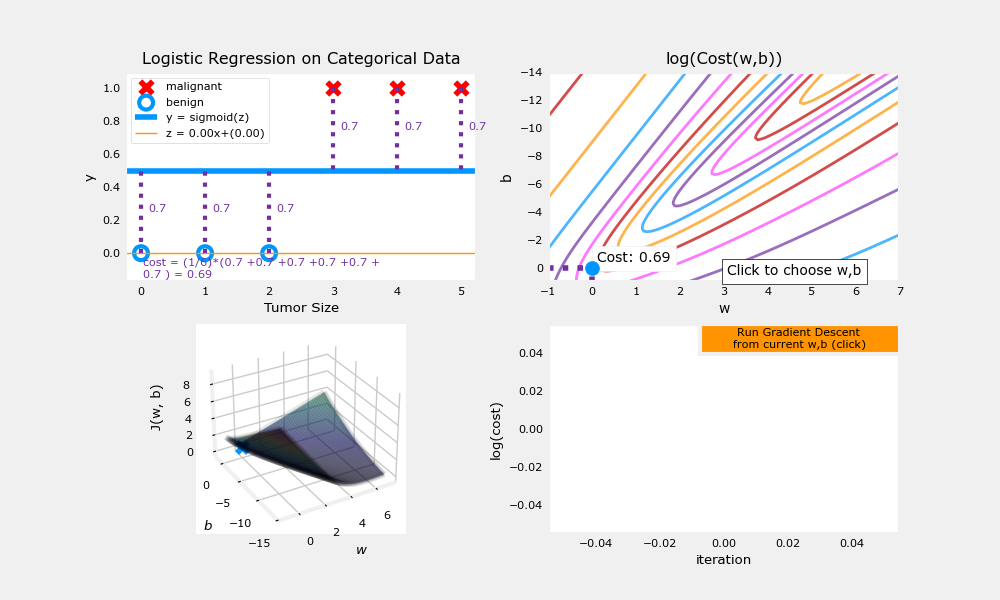

In [9]:
w_range=np.array([-1,7])
b_range=np.array([1,-14])
quad=plt_quad_logistic(x_train,y_train,w_range,b_range)
